# Task 2: Build Time Series Forecasting Models

Objective: develop, train, and evaluate ARIMA/SARIMA and LSTM models to forecast Tesla's closing price, then compare their performance.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## 1. Load Data

Fetch TSLA data for the same period used in Task 1.

In [8]:
TICKER = "TSLA"
START_DATE = "2015-01-01"
END_DATE = "2026-06-30"

df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=False)
df.columns = df.columns.get_level_values(0) if isinstance(df.columns, pd.MultiIndex) else df.columns
df = df[["Adj Close"]].ffill().dropna()
df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close
Date,
2026-06-23,381.609985
2026-06-24,375.529999
2026-06-25,375.119995
2026-06-26,379.709991
2026-06-29,411.839996


## 2. Chronological Train Test Split

The dataset is split by date rather than randomly, since shuffling would break the temporal structure required for time series forecasting.

In [9]:
SPLIT_DATE = "2025-01-01"

train = df[df.index < SPLIT_DATE].copy()
test = df[df.index >= SPLIT_DATE].copy()

print(f"Train period: {train.index.min().date()} to {train.index.max().date()} ({len(train)} rows)")
print(f"Test period: {test.index.min().date()} to {test.index.max().date()} ({len(test)} rows)")

Train period: 2015-01-02 to 2024-12-31 (2516 rows)
Test period: 2025-01-02 to 2026-06-29 (372 rows)


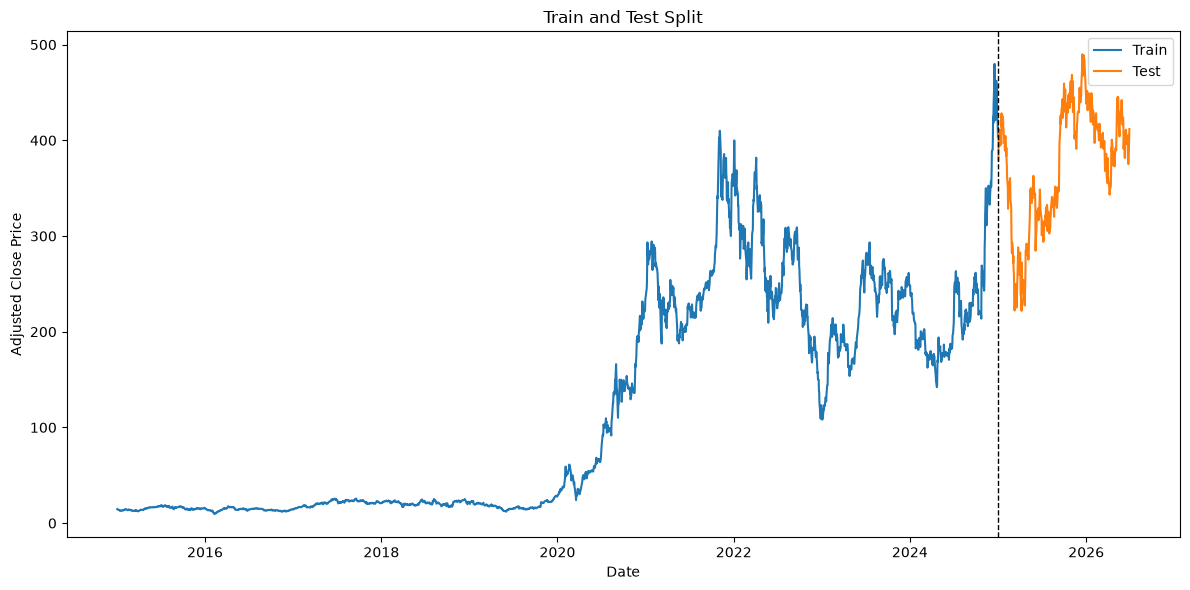

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train.index, train["Adj Close"], label="Train")
ax.plot(test.index, test["Adj Close"], label="Test")
ax.axvline(pd.Timestamp(SPLIT_DATE), color="black", linestyle="--", linewidth=1)
ax.set_title("Train and Test Split")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close Price")
ax.legend()
plt.tight_layout()
plt.show()

The dashed line at 2025 marks a clean chronological split, with train covering 2015 through 2024 and test covering 2025 through mid 2026, and no overlap or shuffling between the two.

## 3. ARIMA and SARIMA Model

The differencing parameter is informed by the Augmented Dickey Fuller test result from Task 1, where the closing price series was found to be non stationary while the daily return series was stationary. This supports a differencing order of one.

The `auto_arima` function is used to search for the optimal (p, d, q) parameters based on information criteria.

In [11]:
from pmdarima import auto_arima

arima_model = auto_arima(
    train["Adj Close"],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
)

print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.29 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.23 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.38 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.621 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Mon, 06 Jul 2026   AIC                          16368.109
Time:                        01:02:37   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                  

In [12]:
n_periods = len(test)
arima_forecast, arima_conf_int = arima_model.predict(n_periods=n_periods, return_conf_int=True)

arima_forecast_series = pd.Series(arima_forecast, index=test.index, name="ARIMA Forecast")
arima_forecast_series.head()

d:\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Date
2025-01-02   NaN
2025-01-03   NaN
2025-01-06   NaN
2025-01-07   NaN
2025-01-08   NaN
Name: ARIMA Forecast, dtype: float64

In [27]:
n_periods = len(test)
arima_forecast, arima_conf_int = arima_model.predict(n_periods=n_periods, return_conf_int=True)

arima_forecast_series = pd.Series(arima_forecast.values, index=test.index, name="ARIMA Forecast")
arima_forecast_series.head()

d:\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Date
2025-01-02    403.839996
2025-01-03    403.839996
2025-01-06    403.839996
2025-01-07    403.839996
2025-01-08    403.839996
Name: ARIMA Forecast, dtype: float64

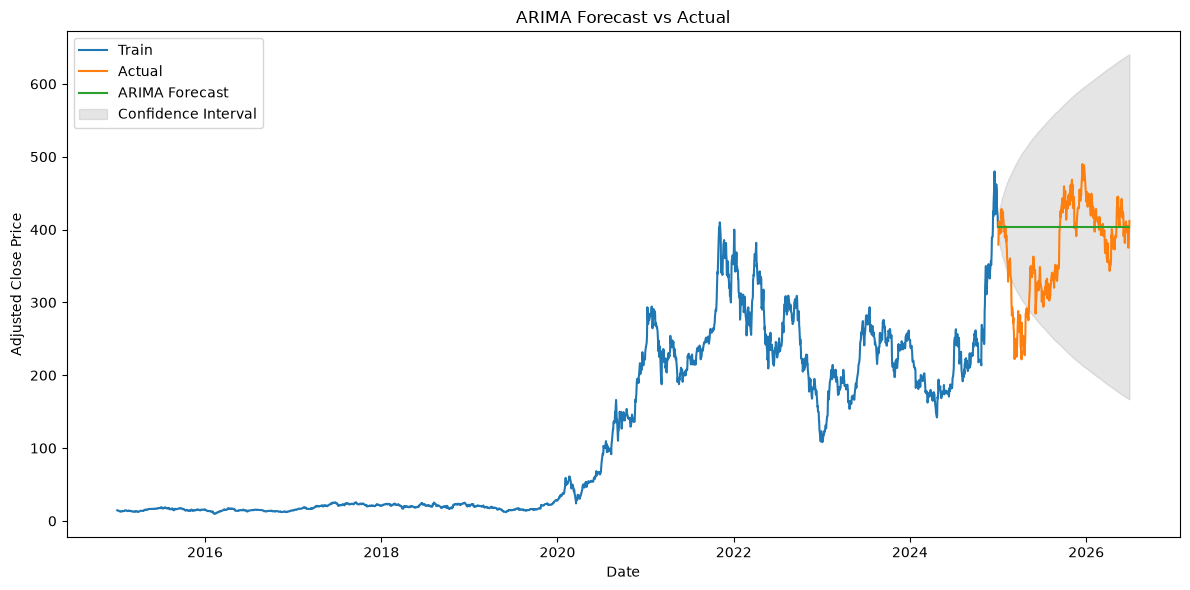

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train.index, train["Adj Close"], label="Train")
ax.plot(test.index, test["Adj Close"], label="Actual")
ax.plot(test.index, arima_forecast_series, label="ARIMA Forecast")
ax.fill_between(test.index, arima_conf_int[:, 0], arima_conf_int[:, 1], color="gray", alpha=0.2, label="Confidence Interval")
ax.set_title("ARIMA Forecast vs Actual")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close Price")
ax.legend()
plt.tight_layout()
plt.show()

The ARIMA forecast is flat at approximately 404 across the entire test
period, since the selected model, ARIMA(0,1,0), is a pure random walk
with no autoregressive or moving average terms. Its best prediction for
any future day is simply the last known training price.

The confidence interval widens from near the actual price range to
roughly 170 to 630 by the end of the horizon, reflecting the compounding
uncertainty of a random walk over time.

Actual TSLA prices show clear movement the flat forecast does not
capture, indicating this model does not adequately fit the series.

## 4. LSTM Model

Sequences of sixty trading days are used to predict the following day's closing price. Data is scaled to the zero to one range before sequence construction, as LSTM networks are sensitive to input scale.

In [14]:
SEQUENCE_LENGTH = 60

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[["Adj Close"]])

full_scaled = scaler.transform(df[["Adj Close"]])
test_start_idx = len(train) - SEQUENCE_LENGTH

def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i - sequence_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, SEQUENCE_LENGTH)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_scaled_window = full_scaled[test_start_idx:]
X_test, y_test = create_sequences(test_scaled_window, SEQUENCE_LENGTH)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (2456, 60, 1)
X_test shape: (372, 60, 1)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1),
])

lstm_model.compile(optimizer="adam", loss="mean_squared_error")
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = lstm_model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
)

Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - loss: 0.0083 - val_loss: 0.0028
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0020 - val_loss: 0.0028
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0015 - val_loss: 0.0024
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 6/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 7/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 8/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0011 - val_loss: 0.0023
Epoch 9/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 10/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 9.3516e-04 - val_loss: 0.0021
Epoch 11/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 9.7816e-04 - val_loss: 0.0016
Epoch 12/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - l

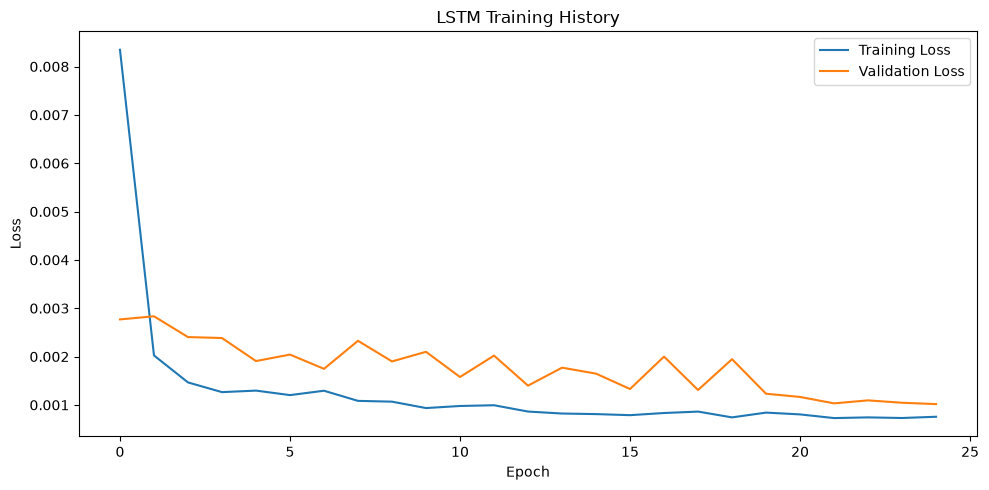

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history["loss"], label="Training Loss")
ax.plot(history.history["val_loss"], label="Validation Loss")
ax.set_title("LSTM Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

Training and validation loss both decreased over time without diverging, indicating the LSTM learned generalizable patterns rather than memorizing the training set.

In [18]:
lstm_pred_scaled = lstm_model.predict(X_test)
lstm_forecast = scaler.inverse_transform(lstm_pred_scaled).flatten()

lstm_forecast_series = pd.Series(lstm_forecast, index=test.index[:len(lstm_forecast)], name="LSTM Forecast")
lstm_forecast_series.head()

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


Date
2025-01-02    425.346832
2025-01-03    409.692047
2025-01-06    402.460754
2025-01-07    401.046631
2025-01-08    399.222504
Name: LSTM Forecast, dtype: float32

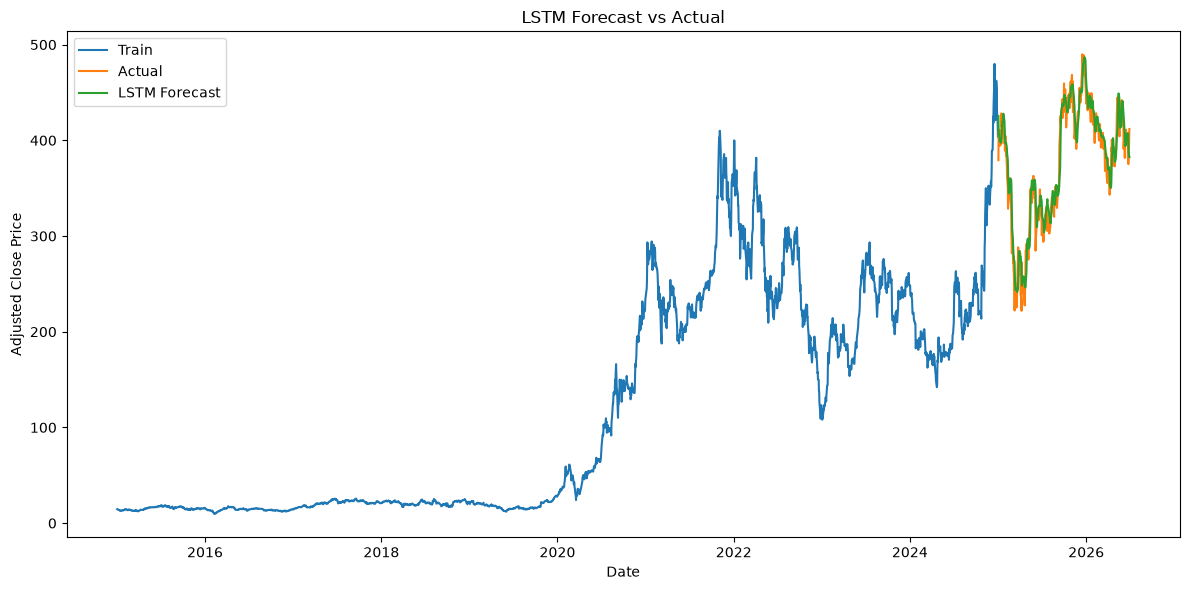

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train.index, train["Adj Close"], label="Train")
ax.plot(test.index, test["Adj Close"], label="Actual")
ax.plot(lstm_forecast_series.index, lstm_forecast_series, label="LSTM Forecast")
ax.set_title("LSTM Forecast vs Actual")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close Price")
ax.legend()
plt.tight_layout()
plt.show()

The LSTM forecast visually reproduces the shape and timing of TSLA's actual price movement, not just its general direction.

## 5. Model Evaluation

Performance is compared using Mean Absolute Error, Root Mean Squared Error, and Mean Absolute Percentage Error.

In [25]:
def evaluate(actual, predicted, label):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {"Model": label, "MAE": mae, "RMSE": rmse, "MAPE": mape}

arima_forecast_series = pd.Series(arima_forecast.values, index=test.index, name="ARIMA Forecast")
arima_metrics = evaluate(test["Adj Close"].values, arima_forecast_series.values, "ARIMA")

lstm_actual = test["Adj Close"].values[:len(lstm_forecast_series)]
lstm_metrics = evaluate(lstm_actual, lstm_forecast_series.values, "LSTM")

comparison_df = pd.DataFrame([arima_metrics, lstm_metrics]).set_index("Model")
comparison_df

,MAE,RMSE,MAPE
Model,,,
ARIMA,54.441182,70.539346,17.240653
LSTM,12.993586,16.577137,3.733209


## 6. Model Selection Discussion

LSTM outperformed ARIMA across all three metrics, with roughly one quarter
the error. LSTM achieved an MAE of 12.99 and RMSE of 16.58, compared to
ARIMA's MAE of 54.44 and RMSE of 70.54. MAPE tells the same story, 3.73
percent for LSTM versus 17.24 percent for ARIMA.

This gap is consistent with the model characteristics observed earlier.
ARIMA(0,1,0) reduces to a random walk with a flat forecast, unable to
react to price movement. LSTM, trained on sixty day sequences, captures
nonlinear patterns in the price history and tracks the actual test period
closely, as shown in the forecast comparison plot.